
RESULTADOS DO LAB 01
 Partículas         w1         w2         w3         w4         w5         w6  Soma dos pesos  Fitness (°C)
         10 0.00000000 0.00000000 0.00000000 1.00000000 0.00000000 0.00000000      1.00000000   30.00000000
         30 0.00000000 0.00000000 0.00000000 1.00000000 0.00000000 0.00000000      1.00000000   30.00000000
         50 0.00000000 0.00000000 0.00000000 1.00000000 0.00000000 0.00000000      1.00000000   30.00000000

Mínimo teórico: 30 °C (100% do tráfego na AZ4).


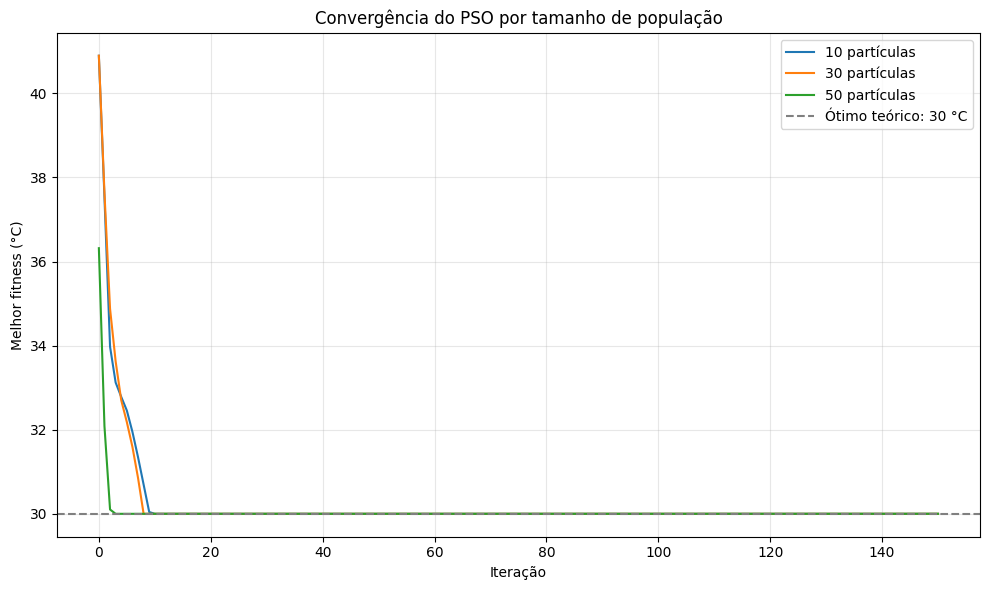

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

C = np.array([42., 35., 58., 30., 50., 65.])
LIMITE = 75.0
PENALIDADE = 1000.0
ITERACOES = 150


def normalizar(posicao):
    p = np.maximum(np.asarray(posicao, dtype=float), 0.0)
    soma = p.sum()
    return p / soma if soma > 0 else np.full(len(p), 1.0 / len(p))


def fitness(pesos, temperaturas=C):
    temp_media = float(np.dot(pesos, temperaturas))
    excesso = np.maximum(temperaturas - LIMITE, 0.0)
    penalidade = PENALIDADE * float(np.dot(pesos, excesso ** 2))
    return temp_media + penalidade


class PSOContinuo:
    def __init__(self, n_particulas, iteracoes=ITERACOES, seed=42,
                 inercia=0.7, cognitivo=1.7, social=1.7):
        self.n = n_particulas
        self.iteracoes = iteracoes
        self.rng = np.random.default_rng(seed)
        self.inercia, self.cognitivo, self.social = inercia, cognitivo, social
        self.posicoes = self.rng.dirichlet(np.ones(6), size=self.n)
        self.velocidades = self.rng.uniform(-0.05, 0.05, size=(self.n, 6))
        self.p_best = self.posicoes.copy()
        self.p_best_fitness = np.array([fitness(p) for p in self.p_best])
        idx = np.argmin(self.p_best_fitness)
        self.g_best = self.p_best[idx].copy()
        self.g_best_fitness = float(self.p_best_fitness[idx])
        self.historico_gbest = [self.g_best_fitness]
        self.historico_media = [float(np.mean(self.p_best_fitness))]
        self.historico_pbest = [self.p_best.copy()]

    def executar(self):
        for _ in range(self.iteracoes):
            r1 = self.rng.random((self.n, 6))
            r2 = self.rng.random((self.n, 6))
            self.velocidades = (self.inercia * self.velocidades
                + self.cognitivo * r1 * (self.p_best - self.posicoes)
                + self.social * r2 * (self.g_best - self.posicoes))
            self.posicoes = np.array([
                normalizar(p) for p in self.posicoes + self.velocidades
            ])
            valores = np.array([fitness(p) for p in self.posicoes])
            melhores = valores < self.p_best_fitness
            self.p_best[melhores] = self.posicoes[melhores]
            self.p_best_fitness[melhores] = valores[melhores]
            idx = np.argmin(self.p_best_fitness)
            if self.p_best_fitness[idx] < self.g_best_fitness:
                self.g_best = self.p_best[idx].copy()
                self.g_best_fitness = float(self.p_best_fitness[idx])
            self.historico_gbest.append(self.g_best_fitness)
            self.historico_media.append(float(np.mean(valores)))
            self.historico_pbest.append(self.p_best.copy())
        return self.g_best.copy(), self.g_best_fitness


def experimento():
    resultados = []
    execucoes = {}
    for n in [10, 30, 50]:
        pso = PSOContinuo(n_particulas=n, seed=42)
        pesos, melhor = pso.executar()
        assert np.all(pesos >= 0) and np.isclose(pesos.sum(), 1.0)
        assert all(np.isclose(p.sum(axis=1), 1.0).all()
                   for p in pso.historico_pbest)
        execucoes[n] = pso
        resultados.append({
            'Partículas': n,
            **{f'w{i+1}': float(pesos[i]) for i in range(6)},
            'Soma dos pesos': float(pesos.sum()),
            'Fitness (°C)': melhor
        })
    tabela = pd.DataFrame(resultados)
    print('\nRESULTADOS DO LAB 01')
    print(tabela.to_string(index=False, float_format=lambda x: f'{x:.8f}'))
    print('\nMínimo teórico: 30 °C (100% do tráfego na AZ4).')
    fig, ax = plt.subplots(figsize=(10, 6))
    for n, pso in execucoes.items():
        ax.plot(pso.historico_gbest, label=f'{n} partículas')
    ax.axhline(30, linestyle='--', color='gray', label='Ótimo teórico: 30 °C')
    ax.set(title='Convergência do PSO por tamanho de população',
           xlabel='Iteração', ylabel='Melhor fitness (°C)')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('lab01_convergencia.png', dpi=160)
    plt.show()
    tabela.to_csv('lab01_resultados.csv', index=False)
    return tabela, execucoes



tabela, execucoes = experimento()
